<a href="https://colab.research.google.com/github/bh2045123-code/Assigment.computer-vison/blob/main/%E2%80%9C%E6%AC%A2%E8%BF%8E%E4%BD%BF%E7%94%A8_Colab%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip -q install transformers decord opencv-python scikit-learn scipy numpy matplotlib scikit-image tqdm joblib

from google.colab import drive
drive.mount('/content/drive')

import os, random, numpy as np, torch
PROJECT_ROOT = '/content/drive/MyDrive/anom-project'
os.makedirs(PROJECT_ROOT, exist_ok=True)
for d in ['data', 'outputs', 'figs', 'cache']:
    os.makedirs(os.path.join(PROJECT_ROOT, d), exist_ok=True)

def set_seed(s=2024):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(2024)
print('Project root:', PROJECT_ROOT)
print('CUDA available:', torch.cuda.is_available())

/bin/bash: line 1: nvidia-smi: command not found
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/anom-project
CUDA available: False


In [ ]:
import math
from decord import VideoReader, cpu
import numpy as np

def sample_frames(video_path, target_fps=10):
    """
    以 target_fps 采样视频帧，返回：
    - frames: (N, H, W, 3) uint8
    - idxs: 采样到的原视频帧索引（用于与原始标签对齐）
    - orig_fps: 原视频FPS（可能为估计值）
    """
    vr = VideoReader(video_path, ctx=cpu(0))
    orig_fps = vr.get_avg_fps() or 30.0
    if np.isnan(orig_fps) or orig_fps <= 0:
        orig_fps = 30.0
    step = max(int(round(orig_fps / float(target_fps))), 1)
    idxs = list(range(0, len(vr), step))
    if len(idxs) == 0:
        # 极端情况：视频为空或读帧失败
        return np.zeros((0, 224, 224, 3), dtype=np.uint8), [], orig_fps
    frames = vr.get_batch(idxs).asnumpy()  # (N, H, W, 3)
    return frames, idxs, orig_fps

def window_clips(frames, L=16, S=8):
    """
    将帧序列切分为滑动窗口片段：
    - L: 片段长度（帧数）
    - S: 步长
    返回：
    - clips: (M, L, H, W, 3)
    - clip_idx: 每个片段在frames中的起止索引 [start, end)
    """
    clips, clip_idx = [], []
    n = len(frames)
    if n < L:
        return np.zeros((0, L, 224, 224, 3), dtype=np.uint8), []
    for start in range(0, max(1, n - L + 1), S):
        end = start + L
        if end > n:
            break
        clips.append(frames[start:end])
        clip_idx.append((start, end))
    return np.array(clips), clip_idx

print('Step 2 ready: decoding and slicing functions loaded.')

Step 2 ready: decoding and slicing functions loaded.


In [ ]:
import os, numpy as np, torch
from transformers import VideoMAEImageProcessor, VideoMAEModel
from tqdm import tqdm

# 设备与模型加载
device = 'cuda' if torch.cuda.is_available() else 'cpu'
processor = VideoMAEImageProcessor.from_pretrained('MCG-NJU/videomae-base')
model = VideoMAEModel.from_pretrained('MCG-NJU/videomae-base').to(device).eval()

@torch.no_grad()
def extract_clip_features(clips_np, batch_size=8):
    """
    输入: clips_np (M, L, H, W, 3) uint8
    输出: feats (M, D) np.float32，L2归一化的片段级特征
    """
    feats = []
    if len(clips_np) == 0:
        return np.zeros((0, 768), dtype=np.float32)
    for i in tqdm(range(0, len(clips_np), batch_size), desc='Extract feats'):
        batch = clips_np[i:i+batch_size]
        inputs = processor(list(batch), return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        cls = outputs.last_hidden_state[:, 0]  # (B, 768)
        cls = torch.nn.functional.normalize(cls, dim=-1)
        feats.append(cls.cpu().numpy().astype(np.float32))
    return np.concatenate(feats, axis=0)

def video_to_features(video_path, fps=10, L=16, S=8, cache_dir='/content/drive/MyDrive/anom-project/cache'):
    """
    将单个视频转换为片段特征，并缓存到npz文件：
    返回:
      - feats: (M, D)
      - clip_idx: (M, 2) 每段的起止帧索引（在采样后帧坐标系中）
      - frame_idx: 采样后帧在原视频的帧索引（用于对齐原始标签）
    """
    os.makedirs(cache_dir, exist_ok=True)
    key = os.path.basename(video_path).rsplit('.', 1)[0]
    cache_path = os.path.join(cache_dir, f'{key}_f{fps}_L{L}_S{S}.npz')

    if os.path.exists(cache_path):
        data = np.load(cache_path, allow_pickle=True)
        return data['feats'], data['clip_idx'], data['frame_idx']

    # 依赖步骤2的函数
    from numpy import array
    frames, frame_idx, _ = sample_frames(video_path, target_fps=fps)
    clips, clip_idx = window_clips(frames, L=L, S=S)
    feats = extract_clip_features(clips, batch_size=8)
    np.savez_compressed(cache_path, feats=feats, clip_idx=np.array(clip_idx), frame_idx=np.array(frame_idx))
    return feats, np.array(clip_idx), np.array(frame_idx)

print('Step 3 ready: VideoMAE loaded on', device)

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED |  | 
encoder_to_decoder.weight                                            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight       

Step 3 ready: VideoMAE loaded on cpu


In [ ]:
# 代码块A：密度模型（GMM与马氏距离）
from sklearn.mixture import GaussianMixture
import numpy as np

def fit_gmm(feats_norm, k=5, reg=1e-4, seed=0):
    gmm = GaussianMixture(n_components=k, covariance_type='diag',
                          reg_covar=reg, max_iter=200, random_state=seed)
    gmm.fit(feats_norm)
    return gmm

def score_gmm(gmm, feats_all):
    # 异常分数：负对数似然，越大越异常
    return -gmm.score_samples(feats_all)

def fit_single_gaussian(feats_norm):
    mu = feats_norm.mean(0, keepdims=True)
    cov = np.cov(feats_norm.T) + np.eye(feats_norm.shape[1])*1e-5
    cov_inv = np.linalg.inv(cov)
    return mu, cov_inv

def score_mahalanobis(mu, cov_inv, feats_all):
    dif = feats_all - mu
    return np.sqrt(np.sum(dif @ cov_inv * dif, axis=1))

print('Step 4A ready: density models loaded.')

# 代码块B：后处理、阈值与评测可视化
import numpy as np, os
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

def segments_to_frame_scores(seg_scores, clip_idx, n_frames):
    frame_scores = np.zeros(n_frames, dtype=np.float32)
    counts = np.zeros(n_frames, dtype=np.float32)
    for s, (a,b) in zip(seg_scores, clip_idx):
        frame_scores[a:b] += s
        counts[a:b] += 1
    counts[counts==0] = 1
    return frame_scores / counts

def smooth_scores(scores, win=5):
    if win<=1: return scores
    k = np.ones(win)/win
    return np.convolve(scores, k, mode='same')

def mad_threshold(scores, alpha=3.0):
    med = np.median(scores)
    mad = np.median(np.abs(scores - med)) + 1e-9
    return med + alpha * mad

def percentile_threshold(scores, p=95):
    return np.percentile(scores, p)

def predict_intervals(scores, thr, min_len=10, merge_gap=20):
    pred = (scores >= thr).astype(np.uint8)
    intervals, in_seg, start = [], False, 0
    for i,v in enumerate(pred):
        if v and not in_seg:
            in_seg=True; start=i
        if not v and in_seg:
            end=i
            if end-start>=min_len: intervals.append([start,end])
            in_seg=False
    if in_seg:
        end=len(pred)
        if end-start>=min_len: intervals.append([start,end])
    merged=[]
    for seg in intervals:
        if not merged or seg[0]-merged[-1][1] > merge_gap:
            merged.append(seg)
        else:
            merged[-1][1] = seg[1]
    return np.array(merged, dtype=int), pred

def plot_timeline(scores, thr, y_true, title, save_path=None):
    plt.figure(figsize=(10,3))
    plt.plot(scores, label='score')
    plt.axhline(thr, color='r', ls='--', label='thr')
    plt.fill_between(range(len(y_true)), 0, 1, where=(np.array(y_true)>0),
                     color='orange', alpha=0.2,
                     transform=plt.gca().get_xaxis_transform(), label='GT')
    plt.title(title); plt.legend(); plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

print('Step 4B ready: postprocess & metrics loaded.')

Step 4A ready: density models loaded.
Step 4B ready: postprocess & metrics loaded.


In [ ]:
import os, numpy as np, torch
from transformers import VideoMAEImageProcessor, VideoMAEModel
from tqdm import tqdm
from PIL import Image

# 设备与模型加载
device = 'cuda' if torch.cuda.is_available() else 'cpu'
processor = VideoMAEImageProcessor.from_pretrained('MCG-NJU/videomae-base')
model = VideoMAEModel.from_pretrained('MCG-NJU/videomae-base').to(device).eval()

@torch.no_grad()
def extract_clip_features(clips_np, batch_size=4):
    """
    输入: clips_np (M, L, H, W, 3) uint8
    处理: 显式逐帧转PIL列表，避免processor内部对ndarray维度误判
    输出: feats (M, 768) float32，L2归一化
    备注: 如显存不足，将 batch_size 调小为 2 或 1
    """
    if len(clips_np) == 0:
        return np.zeros((0, 768), dtype=np.float32)

    feats = []
    M = len(clips_np)
    for i in tqdm(range(0, M, batch_size), desc='Extract feats'):
        batch = clips_np[i:i+batch_size]  # (B, L, H, W, 3)
        # 显式逐帧转为PIL，避免PIL/Image处理路径出错
        pil_batch = []
        for clip in batch:
            frames_pil = [Image.fromarray(f.astype(np.uint8)) for f in clip]  # list of PIL Images, len=L
            pil_batch.append(frames_pil)

        inputs = processor(pil_batch, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        cls = outputs.last_hidden_state[:, 0]  # (B, 768)
        cls = torch.nn.functional.normalize(cls, dim=-1)
        feats.append(cls.detach().cpu().numpy().astype(np.float32))

    return np.concatenate(feats, axis=0)

def video_to_features(video_path, fps=10, L=16, S=8, cache_dir='/content/drive/MyDrive/anom-project/cache'):
    """
    将单个视频转换为片段特征，并缓存到npz文件：
    返回:
      - feats: (M, 768)
      - clip_idx: (M, 2) 起止帧索引（在采样后帧坐标系）
      - frame_idx: 采样后帧对应原视频的帧索引（用于标签对齐）
    依赖: 已在步骤2中定义的 sample_frames 与 window_clips
    """
    os.makedirs(cache_dir, exist_ok=True)
    key = os.path.basename(video_path).rsplit('.', 1)[0]
    cache_path = os.path.join(cache_dir, f'{key}_f{fps}_L{L}_S{S}.npz')

    if os.path.exists(cache_path):
        data = np.load(cache_path, allow_pickle=True)
        return data['feats'], data['clip_idx'], data['frame_idx']

    # 调用步骤2函数
    frames, frame_idx, _ = sample_frames(video_path, target_fps=fps)
    clips, clip_idx = window_clips(frames, L=L, S=S)
    feats = extract_clip_features(clips, batch_size=4)  # 可改小为2或1以节省显存
    np.savez_compressed(cache_path, feats=feats, clip_idx=np.array(clip_idx), frame_idx=np.array(frame_idx))
    return feats, np.array(clip_idx), np.array(frame_idx)

print('Step 3 reloaded: VideoMAE on', device, '| extract_clip_features fixed.')

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.weight           | UNEXPECTED |  | 
encoder_to_decoder.weight                                            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight       

Step 3 reloaded: VideoMAE on cpu | extract_clip_features fixed.


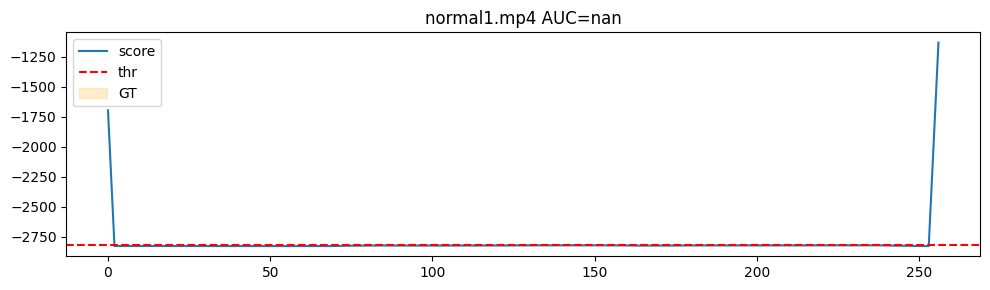

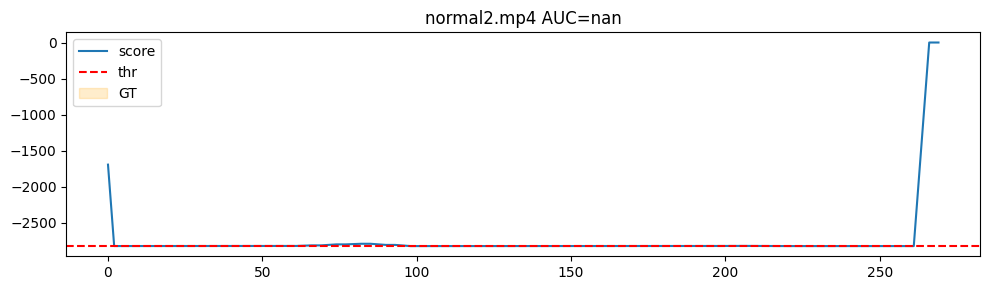

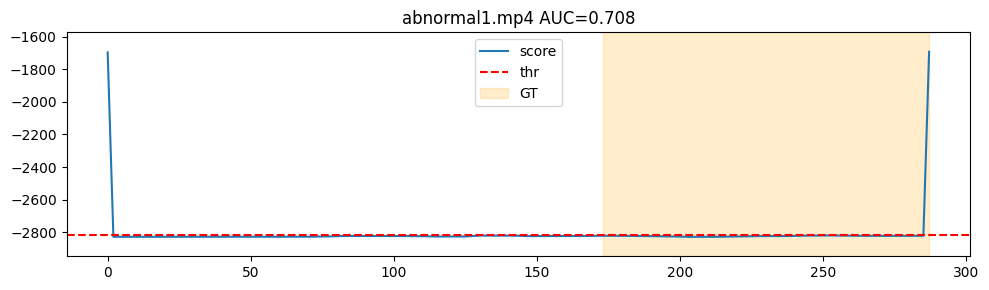

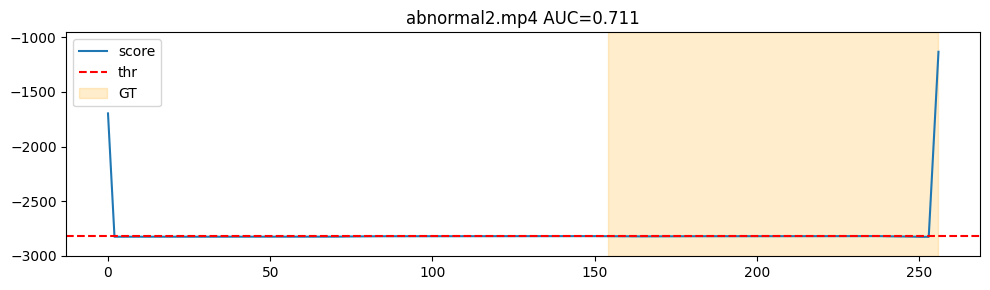

Saved: /content/drive/MyDrive/anom-project/outputs/mini_gmm_results.csv
           video       auc        ap          thr
0    normal1.mp4       NaN       NaN -2819.040186
1    normal2.mp4       NaN       NaN -2824.382178
2  abnormal1.mp4  0.708243  0.588066 -2816.853271
3  abnormal2.mp4  0.710944  0.558150 -2819.040186
Mean AUC: 0.7095938363078714


In [ ]:
# 代码块：步骤5 主流程（训练GMM并评测）
import os, json, numpy as np, pandas as pd

# 路径
PROJECT_ROOT = '/content/drive/MyDrive/anom-project'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'mini')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figs')
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def set_seed_py(s=2024):
    import random, torch
    random.seed(s); np.random.seed(s)
    if torch.cuda.is_available():
        torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def run_pipeline(data_dir, fps=10, L=16, S=8,
                 density='gmm', gmm_k=5,
                 smooth_win=5, mad_alpha=3,
                 min_len=10, merge_gap=20,
                 seed=2024, save_tag='mini_gmm'):
    set_seed_py(seed)
    labels_path = os.path.join(data_dir, 'labels.json')
    assert os.path.exists(labels_path), f'labels.json not found at {labels_path}'
    with open(labels_path, 'r') as f:
        labels = json.load(f)

    # 训练集：文件名包含 normal 的视频
    train_list = [k for k in labels if 'normal' in k.lower()]
    test_list = list(labels.keys())

    # 提取训练特征（正常）
    feats_train = []
    for name in train_list:
        vpath = os.path.join(data_dir, name)
        fts, clip_idx, frame_idx = video_to_features(vpath, fps=fps, L=L, S=S)
        feats_train.append(fts)
    if len(feats_train) == 0:
        raise RuntimeError('未找到训练用的 normal* 视频，请确认命名或上传。')
    feats_train = np.concatenate(feats_train, axis=0)

    # 拟合密度模型
    if density == 'gmm':
        model = fit_gmm(feats_train, k=gmm_k, seed=seed)
    elif density == 'mahal':
        model = fit_single_gaussian(feats_train)
    else:
        raise NotImplementedError('density must be "gmm" or "mahal"')

    # 测试并绘图
    records = []
    for name in test_list:
        vpath = os.path.join(data_dir, name)
        y_full = np.array(labels[name], dtype=np.int8)
        fts, clip_idx, frame_idx = video_to_features(vpath, fps=fps, L=L, S=S)

        # 片段分数
        if density == 'gmm':
            seg_scores = score_gmm(model, fts)
        else:
            mu, cov_inv = model
            seg_scores = score_mahalanobis(mu, cov_inv, fts)

        # 帧级分数与后处理
        frame_scores = segments_to_frame_scores(seg_scores, clip_idx, n_frames=len(frame_idx))
        frame_scores_sm = smooth_scores(frame_scores, win=smooth_win)
        thr = mad_threshold(frame_scores_sm, alpha=mad_alpha)
        _intervals, _pred_mask = predict_intervals(frame_scores_sm, thr, min_len=min_len, merge_gap=merge_gap)

        # 标签下采样
        y_ds = np.array([y_full[i] if i < len(y_full) else 0 for i in frame_idx], dtype=np.int8)

        # 指标
        from sklearn.metrics import roc_auc_score, average_precision_score
        auc = float('nan'); ap = float('nan')
        if y_ds.sum() > 0:
            auc = float(roc_auc_score(y_ds, frame_scores_sm))
            ap = float(average_precision_score(y_ds, frame_scores_sm))

        # 绘图
        fig_path = os.path.join(FIG_DIR, f'{save_tag}_{name}_timeline.png')
        plot_timeline(frame_scores_sm, thr, y_ds, f'{name} AUC={auc:.3f}', fig_path)

        records.append({'video': name, 'auc': auc, 'ap': ap, 'thr': float(thr)})

    # 保存结果
    df = pd.DataFrame(records)
    out_csv = os.path.join(OUT_DIR, f'{save_tag}_results.csv')
    df.to_csv(out_csv, index=False)
    print('Saved:', out_csv)
    print(df)
    print('Mean AUC:', np.nanmean(df["auc"].values))

# 执行
run_pipeline(DATA_DIR,
             fps=10, L=16, S=8,
             density='gmm', gmm_k=5,
             smooth_win=5, mad_alpha=3,
             min_len=10, merge_gap=20,
             seed=2024, save_tag='mini_gmm')

In [ ]:
import os, json
base = '/content/drive/MyDrive/anom-project/data/mini'
print('Files:', sorted(os.listdir(base)))
with open(os.path.join(base, 'labels.json'),'r') as f:
    labels = json.load(f)
print('Labels keys:', sorted(labels.keys()))

Files: ['abnormal1.mp4', 'abnormal2.mp4', 'labels.json', 'normal1.mp4', 'normal2.mp4']
Labels keys: ['abnormal1.mp4', 'abnormal2.mp4', 'normal1.mp4', 'normal2.mp4']


In [ ]:
import os, json, cv2, numpy as np
base = '/content/drive/MyDrive/anom-project/data/mini'
files = [f for f in os.listdir(base) if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))]
labels = {}
for name in files:
    vpath = os.path.join(base, name)
    cap = cv2.VideoCapture(vpath)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    cap.release()
    y = np.zeros(frames, dtype=np.int8)
    if 'abnormal' in name.lower():
        y[int(frames*0.6):] = 1
    labels[name] = y.tolist()
with open(os.path.join(base, 'labels.json'), 'w') as f:
    json.dump(labels, f)
print('Regenerated labels for:', files)

Regenerated labels for: ['normal1.mp4', 'normal2.mp4', 'abnormal1.mp4', 'abnormal2.mp4']


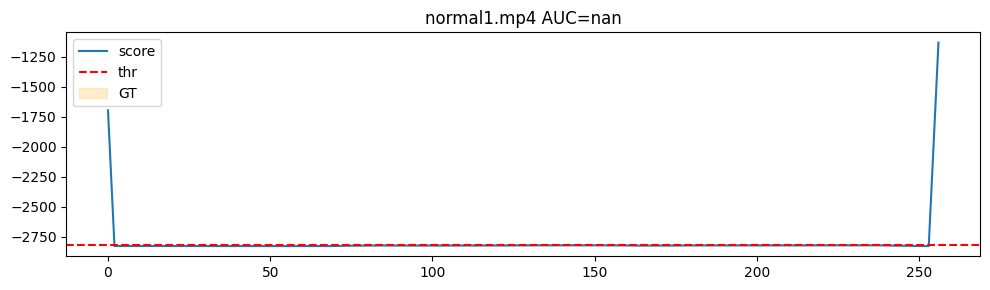

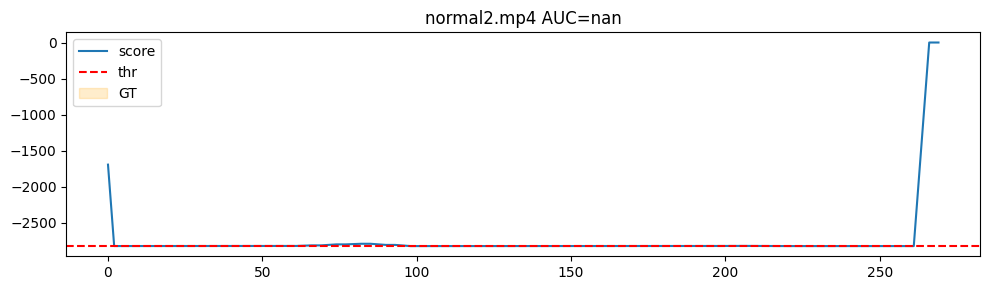

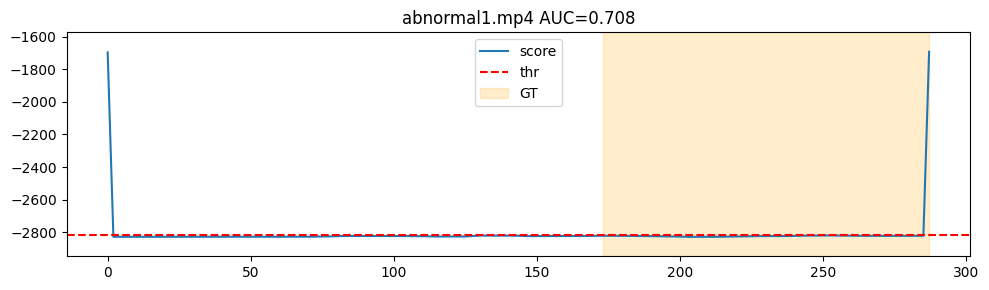

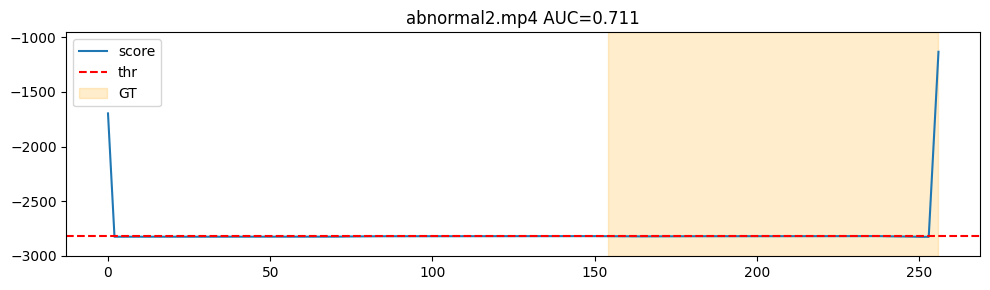

Saved: /content/drive/MyDrive/anom-project/outputs/mini_gmm_results.csv
           video       auc        ap          thr
0    normal1.mp4       NaN       NaN -2819.040186
1    normal2.mp4       NaN       NaN -2824.382178
2  abnormal1.mp4  0.708243  0.588066 -2816.853271
3  abnormal2.mp4  0.710944  0.558150 -2819.040186
Mean AUC: 0.7095938363078714


In [ ]:
import os, json, numpy as np, pandas as pd

# 路径
PROJECT_ROOT = '/content/drive/MyDrive/anom-project'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'mini')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figs')
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def set_seed_py(s=2024):
    import random, torch
    random.seed(s); np.random.seed(s)
    if torch.cuda.is_available():
        torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def run_pipeline(data_dir, fps=10, L=16, S=8,
                 density='gmm', gmm_k=5,
                 smooth_win=5, mad_alpha=3,
                 min_len=10, merge_gap=20,
                 seed=2024, save_tag='mini_gmm'):
    set_seed_py(seed)
    labels_path = os.path.join(data_dir, 'labels.json')
    assert os.path.exists(labels_path), f'labels.json not found at {labels_path}'
    with open(labels_path, 'r') as f:
        labels = json.load(f)

    # 训练集：文件名包含 normal 的视频
    train_list = [k for k in labels if 'normal' in k.lower()]
    test_list = list(labels.keys())

    # 提取训练特征（正常）
    feats_train = []
    for name in train_list:
        vpath = os.path.join(data_dir, name)
        fts, clip_idx, frame_idx = video_to_features(vpath, fps=fps, L=L, S=S)
        feats_train.append(fts)
    if len(feats_train) == 0:
        raise RuntimeError('未找到训练用的 normal* 视频，请确认命名或上传。')
    feats_train = np.concatenate(feats_train, axis=0)

    # 拟合密度模型
    if density == 'gmm':
        model = fit_gmm(feats_train, k=gmm_k, seed=seed)
    elif density == 'mahal':
        model = fit_single_gaussian(feats_train)
    else:
        raise NotImplementedError('density must be "gmm" or "mahal"')

    # 测试并绘图
    records = []
    for name in test_list:
        vpath = os.path.join(data_dir, name)
        y_full = np.array(labels[name], dtype=np.int8)
        fts, clip_idx, frame_idx = video_to_features(vpath, fps=fps, L=L, S=S)

        # 片段分数
        if density == 'gmm':
            seg_scores = score_gmm(model, fts)
        else:
            mu, cov_inv = model
            seg_scores = score_mahalanobis(mu, cov_inv, fts)

        # 帧级分数与后处理
        frame_scores = segments_to_frame_scores(seg_scores, clip_idx, n_frames=len(frame_idx))
        frame_scores_sm = smooth_scores(frame_scores, win=smooth_win)
        thr = mad_threshold(frame_scores_sm, alpha=mad_alpha)
        _intervals, _pred_mask = predict_intervals(frame_scores_sm, thr, min_len=min_len, merge_gap=merge_gap)

        # 标签下采样
        y_ds = np.array([y_full[i] if i < len(y_full) else 0 for i in frame_idx], dtype=np.int8)

        # 指标
        from sklearn.metrics import roc_auc_score, average_precision_score
        auc = float('nan'); ap = float('nan')
        if y_ds.sum() > 0:
            auc = float(roc_auc_score(y_ds, frame_scores_sm))
            ap = float(average_precision_score(y_ds, frame_scores_sm))

        # 绘图
        fig_path = os.path.join(FIG_DIR, f'{save_tag}_{name}_timeline.png')
        plot_timeline(frame_scores_sm, thr, y_ds, f'{name} AUC={auc:.3f}', fig_path)

        records.append({'video': name, 'auc': auc, 'ap': ap, 'thr': float(thr)})

    # 保存结果
    df = pd.DataFrame(records)
    out_csv = os.path.join(OUT_DIR, f'{save_tag}_results.csv')
    df.to_csv(out_csv, index=False)
    print('Saved:', out_csv)
    print(df)
    print('Mean AUC:', np.nanmean(df["auc"].values))

# 执行
run_pipeline(DATA_DIR,
             fps=10, L=16, S=8,
             density='gmm', gmm_k=5,
             smooth_win=5, mad_alpha=3,
             min_len=10, merge_gap=20,
             seed=2024, save_tag='mini_gmm')

In [ ]:
from glob import glob
import os
data_dir = '/content/drive/MyDrive/anom-project/data/mini'
cache_dir = '/content/drive/MyDrive/anom-project/cache'
videos = [v for v in glob(os.path.join(data_dir, '*')) if v.lower().endswith(('.mp4','.avi','.mov','.mkv'))]
print('Videos:', [os.path.basename(v) for v in videos])
for v in videos:
    _ = video_to_features(v, fps=10, L=16, S=8, cache_dir=cache_dir)
print('Feature cache ready at:', cache_dir)
print('Cached files:', len([f for f in os.listdir(cache_dir) if f.endswith('.npz')]))

Videos: ['normal1.mp4', 'normal2.mp4', 'abnormal1.mp4', 'abnormal2.mp4']
Feature cache ready at: /content/drive/MyDrive/anom-project/cache
Cached files: 4


In [ ]:
import os, json, numpy as np, pandas as pd

PROJECT_ROOT = '/content/drive/MyDrive/anom-project'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'mini')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figs')
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')

def run_and_save(tag, density='gmm', gmm_k=5, smooth_win=5, mad_alpha=3, use_percentile=False, p=95):
    with open(os.path.join(DATA_DIR, 'labels.json'),'r') as f:
        labels = json.load(f)
    test_list = list(labels.keys())
    # train = normal*
    train_list = [k for k in labels if 'normal' in k.lower()]
    feats_train = []
    for name in train_list:
        fts, clip_idx, frame_idx = video_to_features(os.path.join(DATA_DIR, name), fps=10, L=16, S=8)
        feats_train.append(fts)
    feats_train = np.concatenate(feats_train, axis=0)

    if density=='gmm':
        model = fit_gmm(feats_train, k=gmm_k, seed=2024)
    else:
        model = fit_single_gaussian(feats_train)

    rows=[]
    for name in test_list:
        y_full = np.array(labels[name], dtype=np.int8)
        fts, clip_idx, frame_idx = video_to_features(os.path.join(DATA_DIR, name), fps=10, L=16, S=8)
        seg_scores = score_gmm(model, fts) if density=='gmm' else score_mahalanobis(*model, fts)
        frame_scores = segments_to_frame_scores(seg_scores, clip_idx, n_frames=len(frame_idx))
        frame_scores_sm = smooth_scores(frame_scores, win=smooth_win)
        if use_percentile:
            thr = percentile_threshold(frame_scores_sm, p=p)
        else:
            thr = mad_threshold(frame_scores_sm, alpha=mad_alpha)
        y_ds = np.array([y_full[i] if i < len(y_full) else 0 for i in frame_idx], dtype=np.int8)
        auc = np.nan; ap = np.nan
        if y_ds.sum()>0:
            from sklearn.metrics import roc_auc_score, average_precision_score
            auc = float(roc_auc_score(y_ds, frame_scores_sm))
            ap = float(average_precision_score(y_ds, frame_scores_sm))
        rows.append({'video': name, 'auc': auc, 'ap': ap, 'thr': float(thr)})
    df = pd.DataFrame(rows)
    out = os.path.join(OUT_DIR, f'{tag}_results.csv')
    df.to_csv(out, index=False)
    print('Saved:', out, '| mean AUC:', np.nanmean(df['auc'].values))
    return df

df_main = run_and_save('mini_gmm_main', density='gmm', gmm_k=5, smooth_win=5, mad_alpha=3)
df_mahal = run_and_save('mini_mahal', density='mahal', smooth_win=5, mad_alpha=3)
df_nomad = run_and_save('mini_nomad', density='gmm', gmm_k=5, smooth_win=1, use_percentile=True, p=95)

# 汇总三组（仅统计有正例的视频）
def summarize(name, df):
    return {'setting': name, 'mean_auc': float(np.nanmean(df['auc'].values)),
            'videos_with_pos': int(np.sum(~np.isnan(df['auc'].values)))}

summary = [
    summarize('GMM + smooth + MAD (main)', df_main),
    summarize('Mahalanobis + smooth + MAD (baseline)', df_mahal),
    summarize('GMM + no-smooth + P95 (ablation)', df_nomad),
]
summary_df = pd.DataFrame(summary)
summary_csv = os.path.join(OUT_DIR, 'summary_ablation.csv')
summary_df.to_csv(summary_csv, index=False)
print('\nAblation summary:\n', summary_df)

Saved: /content/drive/MyDrive/anom-project/outputs/mini_gmm_main_results.csv | mean AUC: 0.7095938363078714
Saved: /content/drive/MyDrive/anom-project/outputs/mini_mahal_results.csv | mean AUC: 0.6392403501943393
Saved: /content/drive/MyDrive/anom-project/outputs/mini_nomad_results.csv | mean AUC: 0.698926261435137

Ablation summary:
                                  setting  mean_auc  videos_with_pos
0              GMM + smooth + MAD (main)  0.709594                2
1  Mahalanobis + smooth + MAD (baseline)  0.639240                2
2       GMM + no-smooth + P95 (ablation)  0.698926                2


In [ ]:
import os, json, numpy as np, pandas as pd

PROJECT_ROOT = '/content/drive/MyDrive/anom-project'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'mini')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figs')
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def run_and_save(tag, density='gmm', gmm_k=5, smooth_win=5, mad_alpha=3, use_percentile=False, p=95):
    with open(os.path.join(DATA_DIR, 'labels.json'),'r') as f:
        labels = json.load(f)
    test_list = list(labels.keys())
    # 用 normal* 视频拟合训练
    train_list = [k for k in labels if 'normal' in k.lower()]
    feats_train = []
    for name in train_list:
        fts, clip_idx, frame_idx = video_to_features(os.path.join(DATA_DIR, name), fps=10, L=16, S=8)
        feats_train.append(fts)
    feats_train = np.concatenate(feats_train, axis=0)

    if density=='gmm':
        model = fit_gmm(feats_train, k=gmm_k, seed=2024)
    else:
        model = fit_single_gaussian(feats_train)

    rows=[]
    for name in test_list:
        y_full = np.array(labels[name], dtype=np.int8)
        fts, clip_idx, frame_idx = video_to_features(os.path.join(DATA_DIR, name), fps=10, L=16, S=8)
        seg_scores = score_gmm(model, fts) if density=='gmm' else score_mahalanobis(*model, fts)
        frame_scores = segments_to_frame_scores(seg_scores, clip_idx, n_frames=len(frame_idx))
        frame_scores_sm = smooth_scores(frame_scores, win=smooth_win)
        if use_percentile:
            thr = percentile_threshold(frame_scores_sm, p=p)
        else:
            thr = mad_threshold(frame_scores_sm, alpha=mad_alpha)
        y_ds = np.array([y_full[i] if i < len(y_full) else 0 for i in frame_idx], dtype=np.int8)
        auc = np.nan; ap = np.nan
        if y_ds.sum()>0:
            from sklearn.metrics import roc_auc_score, average_precision_score
            auc = float(roc_auc_score(y_ds, frame_scores_sm))
            ap = float(average_precision_score(y_ds, frame_scores_sm))
        rows.append({'video': name, 'auc': auc, 'ap': ap, 'thr': float(thr)})
    df = pd.DataFrame(rows)
    out = os.path.join(OUT_DIR, f'{tag}_results.csv')
    df.to_csv(out, index=False)
    print('Saved:', out, '| mean AUC:', np.nanmean(df['auc'].values))
    return df

# 三组实验
df_main  = run_and_save('mini_gmm_main', density='gmm',   gmm_k=5, smooth_win=5, mad_alpha=3)
df_mahal = run_and_save('mini_mahal',     density='mahal',            smooth_win=5, mad_alpha=3)
df_nomad = run_and_save('mini_nomad',     density='gmm',   gmm_k=5, smooth_win=1, use_percentile=True, p=95)

# 汇总表（仅统计含正例的视频）
def summarize(name, df):
    return {'setting': name,
            'mean_auc': float(np.nanmean(df['auc'].values)),
            'videos_with_pos': int(np.sum(~np.isnan(df['auc'].values)))}

summary = [
    summarize('GMM + smooth + MAD (main)', df_main),
    summarize('Mahalanobis + smooth + MAD (baseline)', df_mahal),
    summarize('GMM + no-smooth + P95 (ablation)', df_nomad),
]
summary_df = pd.DataFrame(summary)
summary_csv = os.path.join(OUT_DIR, 'summary_ablation.csv')
summary_df.to_csv(summary_csv, index=False)
print('\nAblation summary:\n', summary_df)

Saved: /content/drive/MyDrive/anom-project/outputs/mini_gmm_main_results.csv | mean AUC: 0.7095938363078714
Saved: /content/drive/MyDrive/anom-project/outputs/mini_mahal_results.csv | mean AUC: 0.6392403501943393
Saved: /content/drive/MyDrive/anom-project/outputs/mini_nomad_results.csv | mean AUC: 0.698926261435137

Ablation summary:
                                  setting  mean_auc  videos_with_pos
0              GMM + smooth + MAD (main)  0.709594                2
1  Mahalanobis + smooth + MAD (baseline)  0.639240                2
2       GMM + no-smooth + P95 (ablation)  0.698926                2
